# Global Hantavirus Surveillance Analysis

# 1. Project Overview

This project analyzes global Hantavirus surveillance data to explore disease distribution, transmission patterns, patient demographics, hospitalization, fatality, recovery, and environmental factors.

The objective is to identify key epidemiological patterns that can support public health agencies in disease monitoring, resource allocation, and prevention strategies.

**Tools Used :**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

# 2. Business Understanding

## Background

Hantavirus is a zoonotic disease that poses significant public health risks in several countries. Understanding disease distribution, transmission patterns, hospitalization, and recovery outcomes is essential for improving surveillance systems and healthcare planning.

## Business Questions

- Which countries report the highest number of Hantavirus cases?
- Which virus strain is most prevalent?
- What are the dominant transmission routes?
- Which demographic groups are most affected?
- How severe are the reported cases based on hospitalization and fatality rates?
- What environmental factors may be associated with disease occurrence?

# 3. Objectives

This analysis aims to:

- Analyze the distribution of Hantavirus cases across countries.
- Identify dominant virus strains and transmission types.
- Explore demographic characteristics of affected patients.
- Evaluate hospitalization and fatality rates.
- Examine recovery patterns and environmental indicators.
- Generate insights to support public health decision-making.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Display setting
pd.set_option('display.max_columns', None)

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Project/Hantavirus/global_hantavirus_surveillance_dataset_2026.csv')
df.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


# 4. Data Understanding

In [61]:
# jumlah row dan kolom
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 19)


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   object 
 1   country                2000 non-null   object 
 2   region                 2000 non-null   object 
 3   report_date            2000 non-null   object 
 4   virus_strain           2000 non-null   object 
 5   transmission_type      2000 non-null   object 
 6   exposure_source        2000 non-null   object 
 7   patient_age            2000 non-null   int64  
 8   gender                 2000 non-null   object 
 9   symptoms               2000 non-null   object 
 10  hospitalization        2000 non-null   object 
 11  fatality               2000 non-null   object 
 12  recovery_days          1845 non-null   float64
 13  temperature_celsius    2000 non-null   float64
 14  humidity_percent       2000 non-null   float64
 15  rode

## Initial Observation

- The dataset contains **2,000 reported Hantavirus cases**.
- The data includes patient demographics, virus strains, transmission routes, environmental conditions, hospitalization status, and recovery information.
- No major data quality issues were identified after the cleaning process.

In [63]:
df.describe()

,patient_age,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
count,2000.000000,1845.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,45.196000,26.293225,24.174850,64.623400,5.494500,10.551500,4968.62350,159.701000
std,19.115001,11.273430,5.981896,17.466002,2.868115,6.369037,2961.87065,81.034152
min,12.000000,7.000000,4.600000,35.000000,1.000000,0.000000,54.00000,20.000000
25%,29.000000,16.000000,20.200000,49.500000,3.000000,5.000000,2341.25000,89.000000
50%,46.000000,27.000000,24.200000,64.550000,5.000000,11.000000,4952.50000,162.000000
75%,62.000000,36.000000,28.000000,79.825000,8.000000,16.000000,7648.75000,231.250000
max,78.000000,45.000000,47.600000,95.000000,10.000000,21.000000,9999.00000,300.000000


In [64]:
df.sample(5)

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
1413,HV2026_01414,Peru,West Lisa,14-08-2025,Sin Nombre,Human-to-Human,Cruise Exposure,22,Female,"Fever, Cough, Headache",Yes,No,43.0,22.3,46.1,1,11,9774,258
1788,HV2026_01789,Chile,Samanthaland,01-08-2025,Andes,Human-to-Human,Home Infestation,24,Male,"Fatigue, Nausea, Chills",No,No,39.0,18.0,59.7,2,0,4061,31
1486,HV2026_01487,Uruguay,Georgeton,08-09-2025,Sin Nombre,Human-to-Human,Rodent Exposure,77,Male,"Fever, Cough, Headache",Yes,No,14.0,32.4,45.2,4,20,8588,113
1786,HV2026_01787,Canada,Evanton,19-03-2026,Seoul,Human-to-Human,Cruise Exposure,65,Female,"Fatigue, Nausea, Chills",Yes,No,42.0,16.1,88.2,9,10,8245,239
898,HV2026_00899,Brazil,Ryanland,23-08-2025,Puumala,Human-to-Human,Warehouse Exposure,74,Female,"Headache, Vomiting, Fever",Yes,No,28.0,14.6,78.8,5,19,635,91


In [65]:
df.columns

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')

In [66]:
df.columns = [
    'case_id',
    'country',
    'region',
    'report_date',
    'virus_strain',
    'transmission_type',
    'exposure_source',
    'patient_age',
    'gender',
    'symptoms',
    'hospitalization',
    'fatality',
    'recovery_days',
    'temperature',
    'humidity',
    'rodent_index',
    'quarantine_days',
    'population_density',
    'air_quality_index'
]

# 5. Data Cleaning

In [67]:
# Missing Value

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Percentage':
    (missing_values.values / len(df))*100
})

missing_df.sort_values(
    by='Missing Count',
    ascending=False
)

,Column,Missing Count,Missing Percentage
12,recovery_days,155,7.75
1,country,0,0.00
0,case_id,0,0.00
2,region,0,0.00
3,report_date,0,0.00
5,transmission_type,0,0.00
4,virus_strain,0,0.00
7,patient_age,0,0.00
8,gender,0,0.00
9,symptoms,0,0.00


In [68]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [69]:
df['report_date'] = pd.to_datetime(
    df['report_date'],
    format='%d-%m-%Y'
)

df['report_date'].head()

,report_date
0,2025-11-24
1,2025-04-22
2,2025-03-21
3,2025-02-10
4,2025-03-25


In [70]:
# membuat flag missing
df['recovery_days_imputed'] = (
    df['recovery_days'].isnull()
)

median_recovery = (
    df['recovery_days']
    .median()
)

df['recovery_days'].fillna(median_recovery, inplace=True)
df.isnull().sum()


,0
case_id,0
country,0
region,0
report_date,0
virus_strain,0
transmission_type,0
exposure_source,0
patient_age,0
gender,0
symptoms,0


# 6. Exploratory Data Analysis

## Business Question 1

What is the overall overview of Hantavirus cases, hospitalization, and fatality rates?

In [71]:
total_cases = len(df)

print("Total Cases:", total_cases)

Total Cases: 2000


In [72]:
# Hospitalization rate

hospital_rate = (
    df['hospitalization']
    .value_counts(normalize=True)
    *100
)

hospital_rate

,proportion
hospitalization,
Yes,50.35
No,49.65


In [73]:
# Fatality rate

fatality_rate = (
    df['fatality']
    .value_counts(normalize=True)
    *100
)

fatality_rate

,proportion
fatality,
No,92.25
Yes,7.75


### Insight

The dataset contains **2,000 reported Hantavirus cases**. Approximately **50.35%** of patients required hospitalization, while the **fatality rate was 7.75%**, indicating that although many cases required medical care, most patients survived.

## Business Question 2

Which countries reported the highest number of Hantavirus cases?

In [74]:
# Top affected countries

country_cases = (
    df['country']
    .value_counts()
    .head(10)
)

country_cases

,count
country,
Bolivia,215
Argentina,211
Canada,208
USA,208
Brazil,207
Uruguay,202
Mexico,196
Paraguay,193
Chile,190


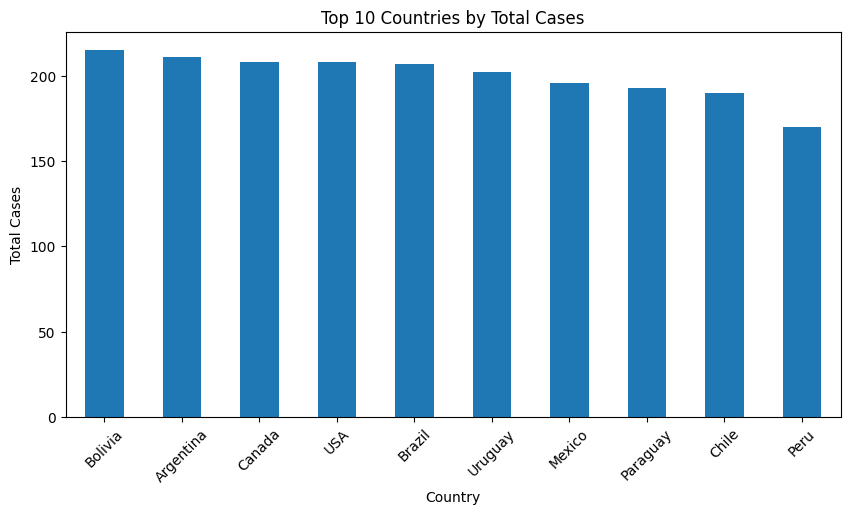

In [75]:
plt.figure(figsize=(10,5))

country_cases.plot(kind='bar')

plt.title('Top 10 Countries by Total Cases')
plt.xlabel('Country')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.show()

### Insight

Bolivia reported the highest number of Hantavirus cases, followed by Argentina, Canada, and the United States. These countries may require stronger disease surveillance and prevention efforts due to their relatively high case counts.

## Business Question 3

Which Hantavirus strains are most frequently reported?

In [76]:
strain_dist = (
    df['virus_strain']
    .value_counts()
)

strain_dist

,count
virus_strain,
Sin Nombre,431
Seoul,414
Andes,394
Dobrava,387
Puumala,374


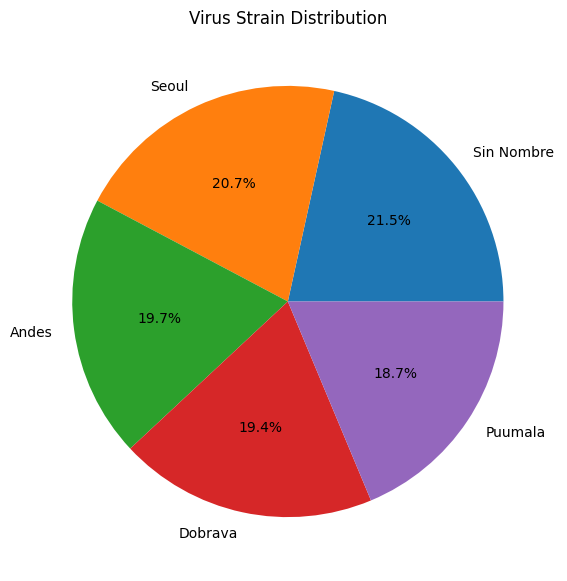

In [77]:
plt.figure(figsize=(7,7))
plt.pie(
    strain_dist,
    labels=strain_dist.index,
    autopct='%1.1f%%'
)
plt.title('Virus Strain Distribution')
plt.show()

### Insight

The Sin Nombre strain is the most frequently reported virus strain, accounting for approximately 21.5% of all cases. The distribution of other strains is relatively balanced, indicating that multiple virus strains contribute to Hantavirus infections.

## Business Question 4

What are the most common transmission types of Hantavirus?

In [78]:
transmission = (
    df['transmission_type']
    .value_counts()
)

transmission

,count
transmission_type,
Human-to-Human,1001
Rodent-to-Human,999


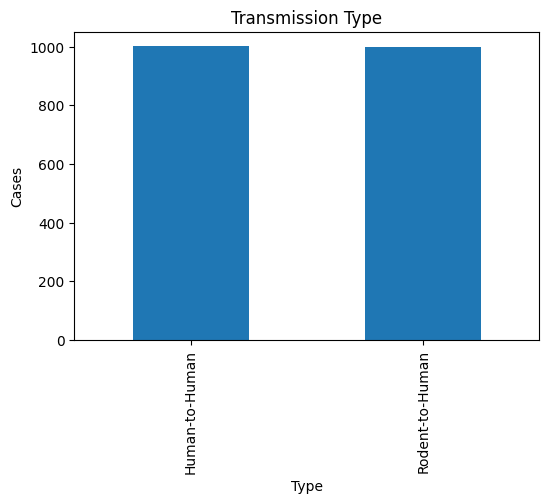

In [79]:
plt.figure(figsize=(6,4))

transmission.plot(
    kind='bar'
)

plt.title(
    'Transmission Type'
)

plt.xlabel('Type')
plt.ylabel('Cases')

plt.show()

### Insight

The Sin Nombre strain is the most frequently reported virus strain, accounting for approximately 21.5% of all cases. The distribution of other strains is relatively balanced, indicating that multiple virus strains contribute to Hantavirus infections.

## Business Question 5

What are the most common exposure sources associated with Hantavirus cases?


In [80]:
exposure = (
    df['exposure_source']
    .value_counts()
)

exposure

,count
exposure_source,
Cruise Exposure,354
Warehouse Exposure,346
Rodent Exposure,336
Home Infestation,331
Forest Exposure,325
Agricultural Exposure,308


### Insight

Cruise exposure is the most frequently reported exposure source, followed by warehouse exposure and rodent exposure. The relatively balanced distribution suggests that Hantavirus exposure can occur across various environments rather than a single dominant setting.

## Business Question 6

What are the demographic characteristics of Hantavirus patients?

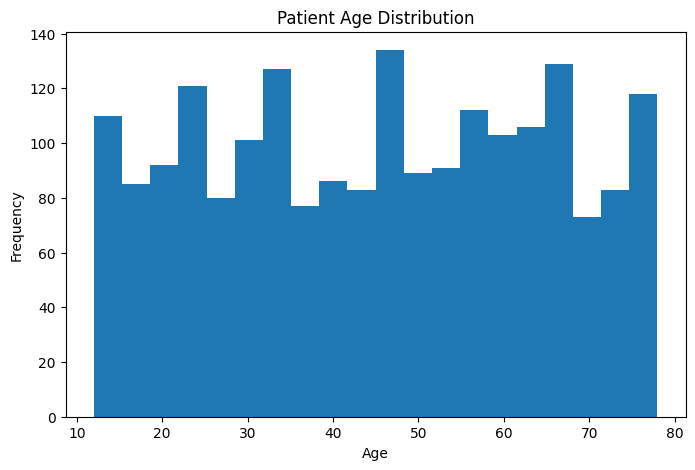

In [81]:
# Age distribution

plt.figure(figsize=(8,5))

plt.hist(df['patient_age'], bins=20)

plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

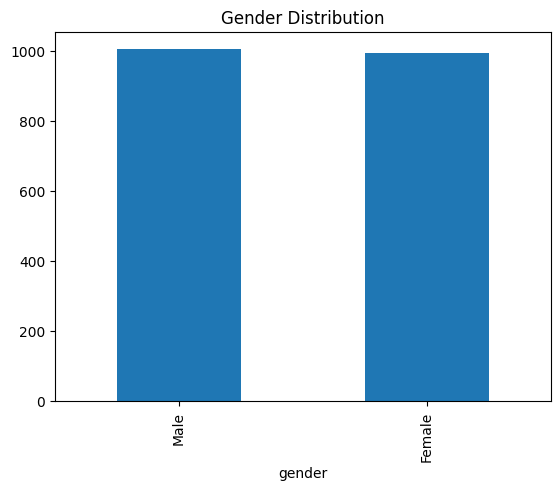

In [82]:
# Gender distribution

gender_dist = (df['gender'].value_counts())
gender_dist.plot(kind='bar')
plt.title('Gender Distribution')
plt.show()

### Insight

Patient ages are distributed across a wide range without a dominant age group. In addition, the number of male and female patients is nearly equal, indicating that reported cases are evenly distributed across genders.

## Business Question 7

Does hospitalization vary between male and female patients?

In [83]:
# Hospitalization by Gender

hospital_gender = pd.crosstab(
    df['gender'],
    df['hospitalization']
)

hospital_gender

hospitalization,No,Yes
gender,,
Female,508,487
Male,485,520


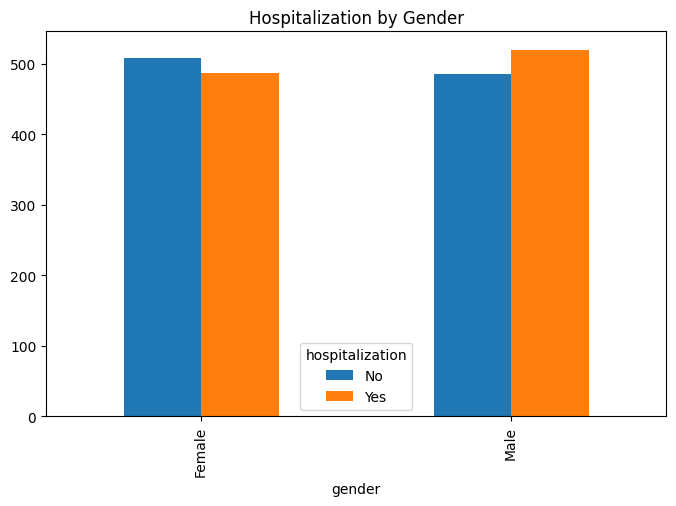

In [84]:
hospital_gender.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Hospitalization by Gender'
)

plt.show()

### Insight

Hospitalization rates are relatively similar between male and female patients, with only a slight difference observed. This suggests that gender alone may not strongly influence hospitalization outcomes.

## Business Question 8

How does hospitalization differ across age groups?

In [85]:
def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 35:
        return 'Young Adult'
    elif age < 55:
        return 'Adult'
    else:
        return 'Senior'


df['age_group'] = (
    df['patient_age']
    .apply(age_group)
)

df[['patient_age',
    'age_group']].head()

,patient_age,age_group
0,26,Young Adult
1,41,Adult
2,39,Adult
3,49,Adult
4,59,Senior


In [86]:
# Hospitalization by Age Group

hospital_age = pd.crosstab(
    df['age_group'],
    df['hospitalization']
)

hospital_age

hospitalization,No,Yes
age_group,,
Adult,303,290
Child,93,73
Senior,362,362
Young Adult,235,282


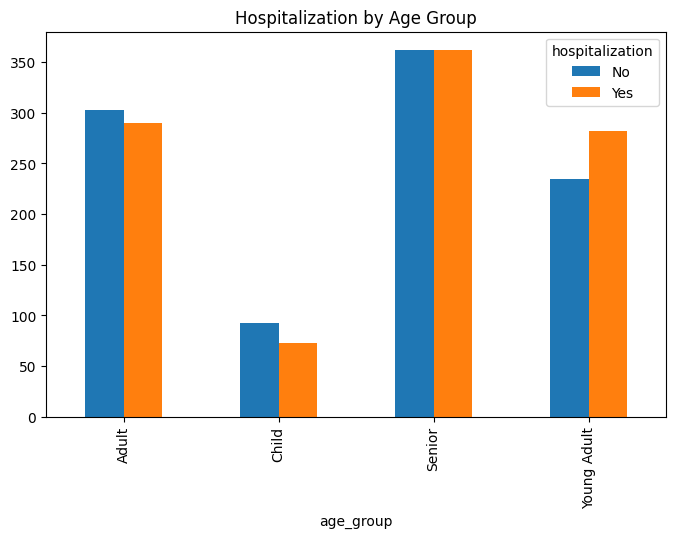

In [87]:
hospital_age.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Hospitalization by Age Group'
)

plt.show()

### Insight

Hospitalization is observed across all age groups, with adults and seniors accounting for the largest number of hospitalized patients. This reflects both their higher representation in the dataset and the need for continued monitoring of these age groups.

## Business Question 9

How does the fatality rate vary across different Hantavirus strains?

In [88]:
# Fatality by Virus Strain

fatality_strain = pd.crosstab(
    df['virus_strain'],
    df['fatality']
)

fatality_strain

fatality,No,Yes
virus_strain,,
Andes,364,30
Dobrava,354,33
Puumala,349,25
Seoul,378,36
Sin Nombre,400,31


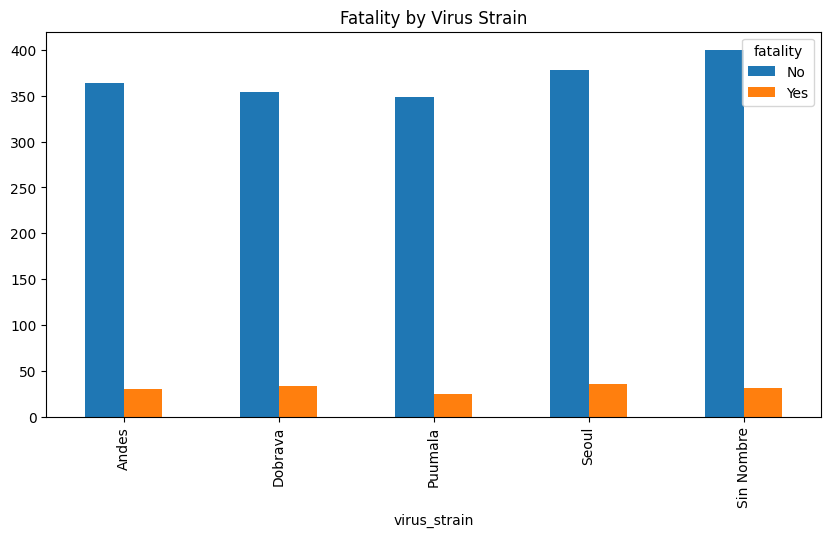

In [89]:
fatality_strain.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Fatality by Virus Strain'
)

plt.show()

### Insight

Fatality cases are relatively low across all virus strains compared to survival cases. Although slight differences exist, no single virus strain shows a  substantially higher fatality count than the others.

## Business Question 10

How does recovery time differ among Hantavirus strains?

In [90]:
# Average recovery days

avg_recovery = (
    df['recovery_days']
    .mean()
)

print(
    "Average Recovery:",
    round(avg_recovery,2)
)

Average Recovery: 26.35


In [91]:
# Recovery by Virus Strain

recovery_strain = (
    df.groupby(
        'virus_strain'
    )['recovery_days']
    .mean()
    .sort_values(
        ascending=False
    )
)

recovery_strain

,recovery_days
virus_strain,
Puumala,26.994652
Dobrava,26.697674
Andes,26.500000
Sin Nombre,26.074246
Seoul,25.577295


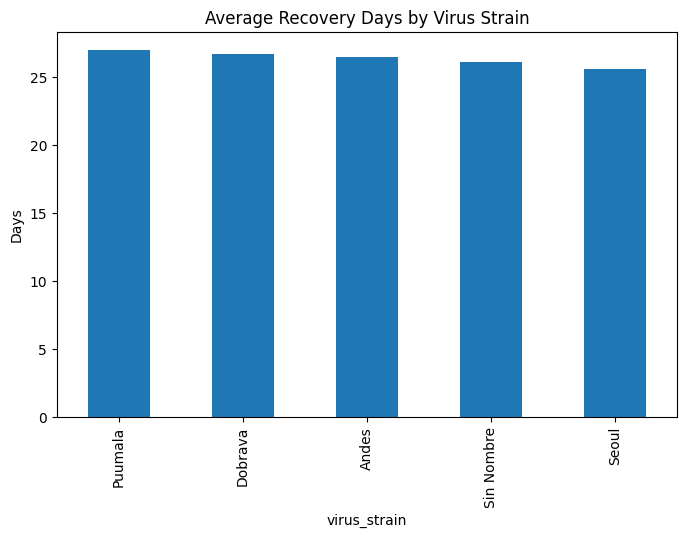

In [92]:
plt.figure(figsize=(8,5))

recovery_strain.plot(
    kind='bar'
)

plt.title(
    'Average Recovery Days by Virus Strain'
)

plt.ylabel('Days')

plt.show()

### Insight

The average recovery time is approximately **26.35 days**, with only minor differences among virus strains. This indicates that recovery duration is generally consistent regardless of the infecting strain.

## Business Question 11

What are the most commonly reported symptoms among Hantavirus patients?

In [93]:
from collections import Counter

all_symptoms = []

for symptom in df['symptoms']:
    split_symptoms = (
        symptom.split(',')
    )

    split_symptoms = [
        s.strip()
        for s in split_symptoms
    ]

    all_symptoms.extend(
        split_symptoms
    )

symptom_count = Counter(
    all_symptoms
)

symptom_df = pd.DataFrame(
    symptom_count.items(),
    columns=[
        'Symptom',
        'Count'
    ]
)

symptom_df.sort_values(
    by='Count',
    ascending=False
).head(10)

,Symptom,Count
2,Fever,1605
4,Fatigue,800
0,Headache,798
3,Muscle Pain,405
5,Cough,404
8,Shortness of Breath,402
6,Nausea,395
7,Chills,395
1,Vomiting,394


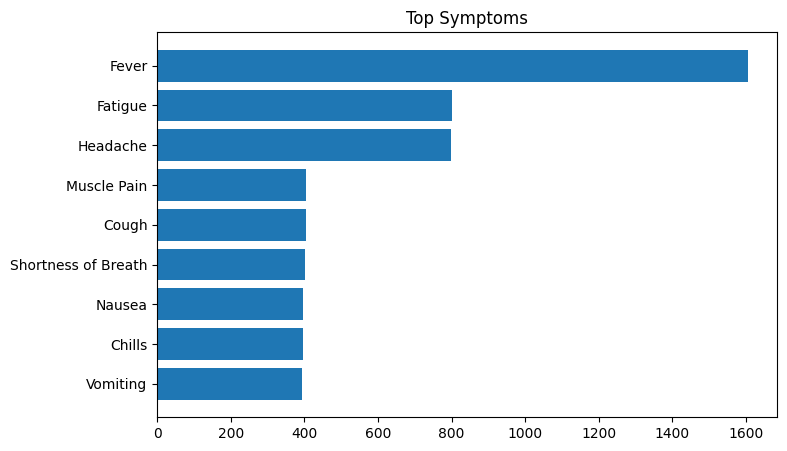

In [94]:
top_symptoms = (
    symptom_df
    .sort_values(
        by='Count',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(8,5))

plt.barh(
    top_symptoms['Symptom'],
    top_symptoms['Count']
)

plt.title(
    'Top Symptoms'
)

plt.gca().invert_yaxis()

plt.show()

### Insight

Fever is the most frequently reported symptom, followed by fatigue and headache. These symptoms represent the most common clinical presentations and can support early identification of suspected Hantavirus cases.

## Business Question 12

Are environmental factors associated with Hantavirus cases and recovery outcomes?

In [95]:
numerical_cols = [
    'patient_age',
    'recovery_days',
    'temperature',
    'humidity',
    'rodent_index',
    'quarantine_days',
    'population_density',
    'air_quality_index'
]

corr_matrix = (
    df[numerical_cols]
    .corr()
)

corr_matrix

,patient_age,recovery_days,temperature,humidity,rodent_index,quarantine_days,population_density,air_quality_index
patient_age,1.000000,-0.030461,0.047880,0.021834,0.032604,-0.029849,-0.001791,0.014290
recovery_days,-0.030461,1.000000,-0.017793,0.016640,-0.022890,-0.021352,-0.029805,0.019969
temperature,0.047880,-0.017793,1.000000,0.017021,-0.018067,-0.009951,0.029780,0.010565
humidity,0.021834,0.016640,0.017021,1.000000,-0.007670,0.001959,-0.021228,-0.002619
rodent_index,0.032604,-0.022890,-0.018067,-0.007670,1.000000,0.013516,0.001037,-0.022825
quarantine_days,-0.029849,-0.021352,-0.009951,0.001959,0.013516,1.000000,-0.012867,0.011498
population_density,-0.001791,-0.029805,0.029780,-0.021228,0.001037,-0.012867,1.000000,0.008978
air_quality_index,0.014290,0.019969,0.010565,-0.002619,-0.022825,0.011498,0.008978,1.000000


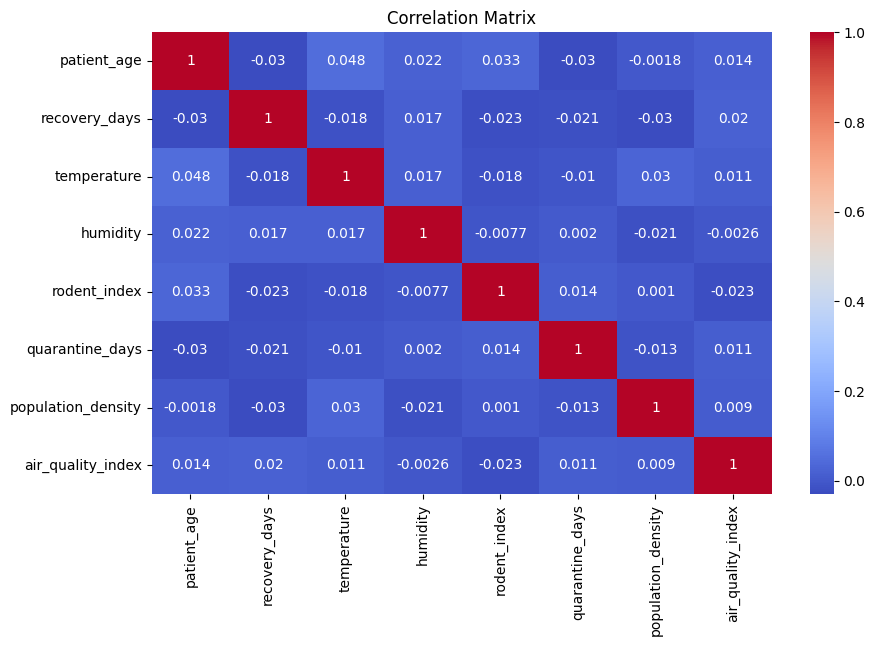

In [96]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Matrix'
)

plt.show()

### Insight

The correlation analysis shows that environmental variables, patient age, and recovery days have very weak relationships with one another. This suggests that no single environmental factor strongly influences recovery outcomes in the current dataset.

## Business Question 13

How have reported Hantavirus cases changed over time?

In [97]:
df['report_date'] = pd.to_datetime(
    df['report_date']
)

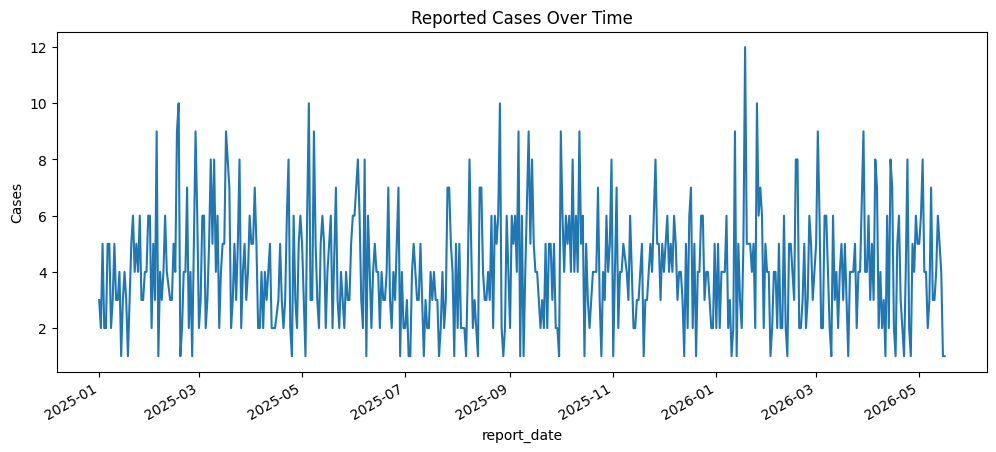

In [98]:
trend = (
    df.groupby('report_date').size())

plt.figure(figsize=(12,5))
trend.plot()
plt.title('Reported Cases Over Time')
plt.ylabel('Cases')
plt.show()

### Insight

Reported Hantavirus cases fluctuate over time without showing a clear upward or downward trend. This indicates that case reports remain relatively stable, with periodic increases on certain dates.

## Business Question 14

How have Hantavirus cases changed over time?

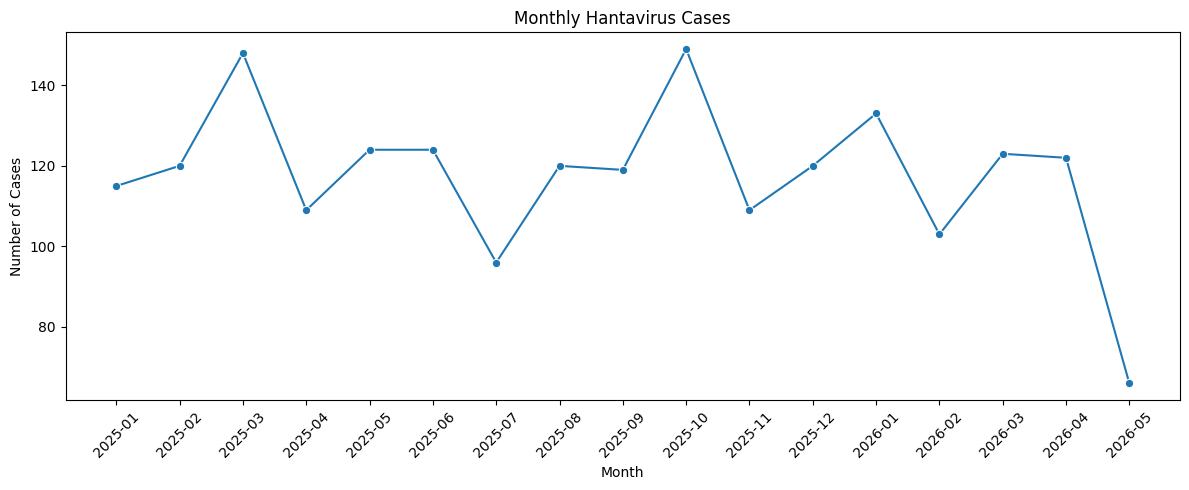

In [99]:
# Monthly trend
monthly_cases = df.groupby(df['report_date'].dt.to_period('M')).size()

monthly_cases.index = monthly_cases.index.astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_cases.index, y=monthly_cases.values, marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Hantavirus Cases")
plt.xlabel("Month")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

### Insight

Reported Hantavirus cases fluctuate throughout the year, with several noticeable peaks and declines. This pattern suggests periodic changes in disease activity, highlighting the importance of continuous surveillance and timely public health interventions.

## Business Question 15

Which virus strains are associated with longer recovery periods?

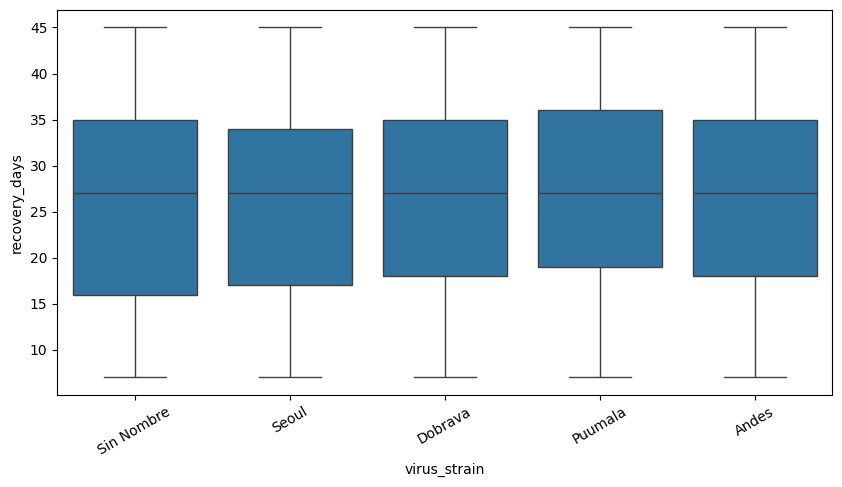

In [100]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x="virus_strain",
    y="recovery_days"
)

plt.xticks(rotation=30)
plt.show()

### Insight

Recovery duration is relatively similar across all virus strains, with only minor differences in the median and distribution. This suggests that recovery time is likely influenced by additional factors beyond the virus strain alone.

## Business Question 16

Which symptom combinations are most common among hospitalized patients?

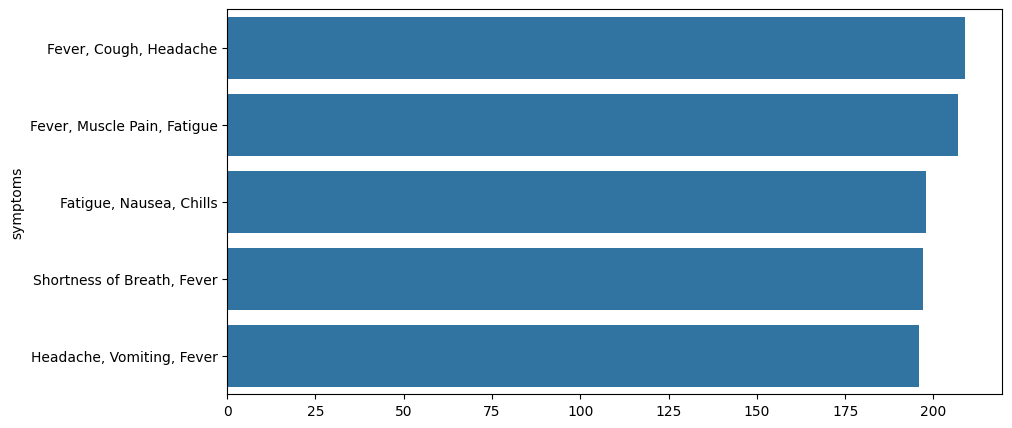

In [101]:
hospital_symptom = (
    df[df["hospitalization"]=="Yes"]
    ["symptoms"]
    .value_counts()
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=hospital_symptom.values,
    y=hospital_symptom.index
)

plt.show()

### Insight

The most frequently reported symptom combinations among hospitalized patients include fever, headache, cough, and fatigue. These recurring symptoms may help healthcare providers identify patients who require closer monitoring and early treatment.

# 14. Key Findings

The analysis of 2,000 Hantavirus cases revealed several important findings:

- The dataset contains **2,000 reported Hantavirus cases**, with **50.35%** of patients requiring hospitalization and a **7.75% fatality rate**, indicating that most patients survived despite a relatively high hospitalization rate.
- Bolivia reported the highest number of cases, followed by Argentina, Canada, and the United States, suggesting these countries experience a higher disease burden in the dataset.
- The **Sin Nombre** strain was the most frequently reported virus strain, although the distribution of virus strains was relatively balanced overall.
- Human-to-human transmission occurred slightly more often than rodent-to-human transmission, highlighting multiple transmission pathways.
- Cruise exposure, warehouse exposure, and rodent exposure were the most common reported exposure sources.
- Patient cases were distributed across various age groups, with a nearly equal distribution between male and female patients. Hospitalization patterns were also relatively similar across genders and age groups.
- Fever, fatigue, and headache were the most frequently reported symptoms among Hantavirus patients.
- The average recovery time was approximately **26.35 days**, with only minor differences across virus strains.
- Correlation analysis showed very weak relationships among environmental variables, patient age, and recovery duration, suggesting no strong linear association in the available data.
- Reported cases fluctuated over time without a clear increasing or decreasing trend.



# 15. Business Recommendations

Based on the analysis, the following recommendations are proposed:

- Prioritize disease surveillance and prevention programs in countries reporting the highest number of cases, particularly Bolivia and Argentina.
- Strengthen public health education on both human-to-human and rodent-related transmission to reduce infection risks.
- Improve early detection by increasing awareness of common symptoms such as fever, fatigue, and headache among healthcare providers and the public.
- Maintain adequate healthcare resources to manage hospitalization demand, as approximately half of reported patients required hospital care.
- Continue monitoring all virus strains, as fatality cases occur across multiple strains without a single dominant high-risk strain.
- Implement preventive measures across multiple exposure settings, including workplaces, residential areas, and travel-related environments.
- Enhance continuous disease surveillance by combining epidemiological data with environmental monitoring to support early outbreak detection and informed public health decision-making.

# 16. Executive Summary

This project analyzed 2,000 global Hantavirus surveillance records to explore disease distribution, transmission patterns, patient demographics, hospitalization outcomes, recovery duration, symptoms, environmental factors, and temporal trends.

The analysis showed that approximately half of all reported patients required hospitalization, while the fatality rate remained relatively low at 7.75%. Bolivia reported the highest number of confirmed cases, and the Sin Nombre strain was the most frequently identified virus strain. Human-to-human transmission slightly exceeded rodent-to-human transmission, emphasizing the importance of multiple prevention strategies. Fever, fatigue, and headache emerged as the most common symptoms, while recovery time remained relatively consistent across virus strains.

Overall, the findings provide valuable insights into Hantavirus epidemiology and can support public health agencies in strengthening disease surveillance, improving healthcare preparedness, and implementing targeted prevention strategies through data-driven decision-making.

# 17. Export Dataset

In [102]:
df.to_csv(
    'cleaned_hantavirus_dataset.csv',
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [103]:
from google.colab import files

files.download(
    'cleaned_hantavirus_dataset.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [104]:
symptom_df.to_csv(
'symptoms_analysis.csv',
index=False
)